In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries loaded")

Libraries loaded


In [2]:
rfm = pd.read_csv("../data/processed/rfm_table.csv")

print("Shape:", rfm.shape)
rfm.head()

Shape: (5878, 10)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Score_Sum,Segment
0,12346,326,12,77556.46,2,5,5,255,12,At Risk
1,12347,2,8,5633.32,5,4,5,545,14,Champions
2,12348,75,5,2019.40,3,4,4,344,11,Loyal Customers
3,12349,19,4,4428.69,5,3,5,535,13,Loyal Customers
4,12350,310,1,334.40,2,1,2,212,5,Lost


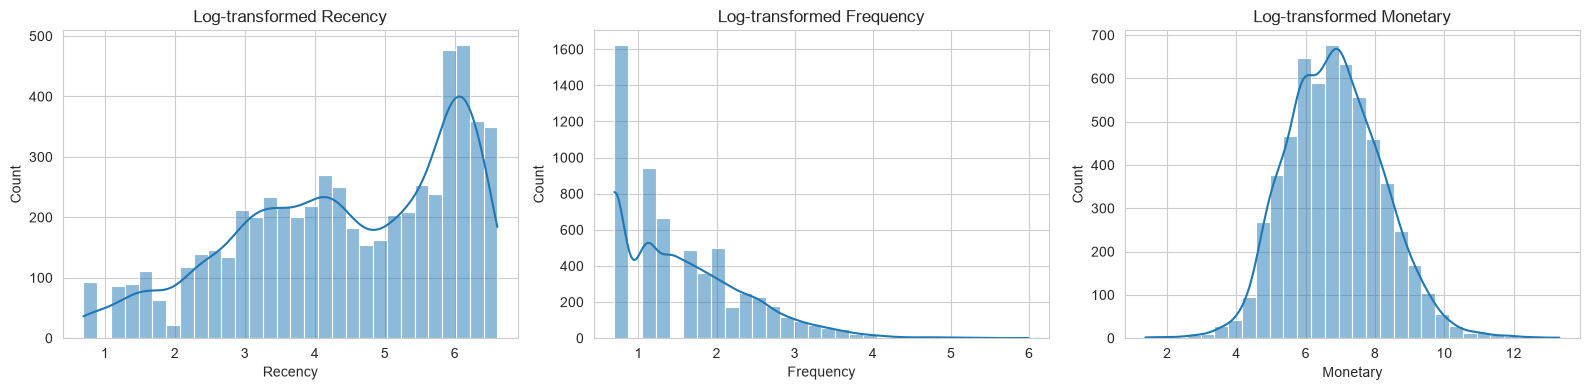

In [6]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(
    lambda x: np.log1p(x)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(
    axes,
    ['Recency', 'Frequency', 'Monetary']
):
    sns.histplot(
        rfm_log[col],
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(f'Log-transformed {col}')
    ax.set_xlabel(col)

plt.tight_layout()

plt.savefig(
    '../images/rfm_log_distributions.png',
    dpi=150
)

plt.show()

In [7]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,0.856701,1.254496,3.186625
1,-2.151979,0.800166,1.297127
2,-0.079138,0.299207,0.558100
3,-0.935308,0.073946,1.123790
4,0.824527,-1.058146,-0.735888


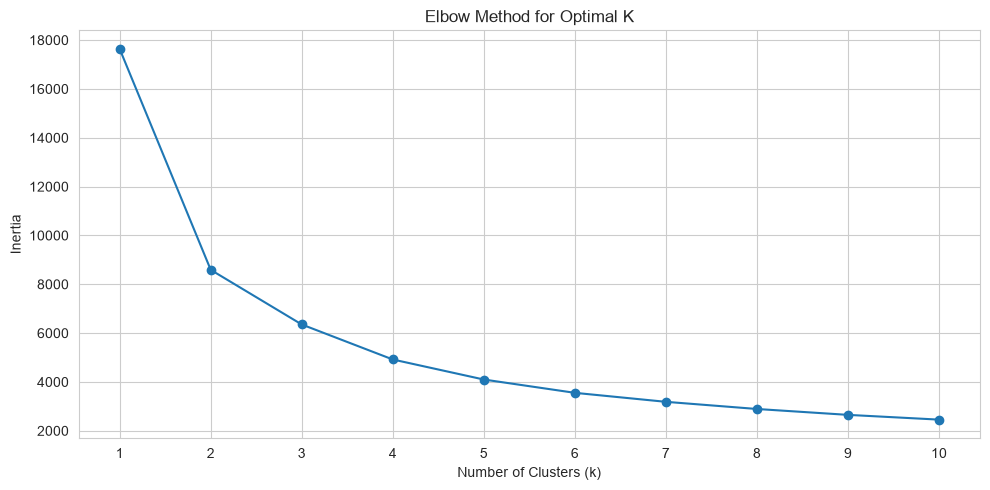

In [8]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))

plt.plot(
    k_range,
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))

plt.tight_layout()

plt.savefig(
    '../images/elbow_method.png',
    dpi=150
)

plt.show()

k=2: silhouette score = 0.4381
k=3: silhouette score = 0.3478
k=4: silhouette score = 0.3653
k=5: silhouette score = 0.3421
k=6: silhouette score = 0.3336
k=7: silhouette score = 0.3052
k=8: silhouette score = 0.2970


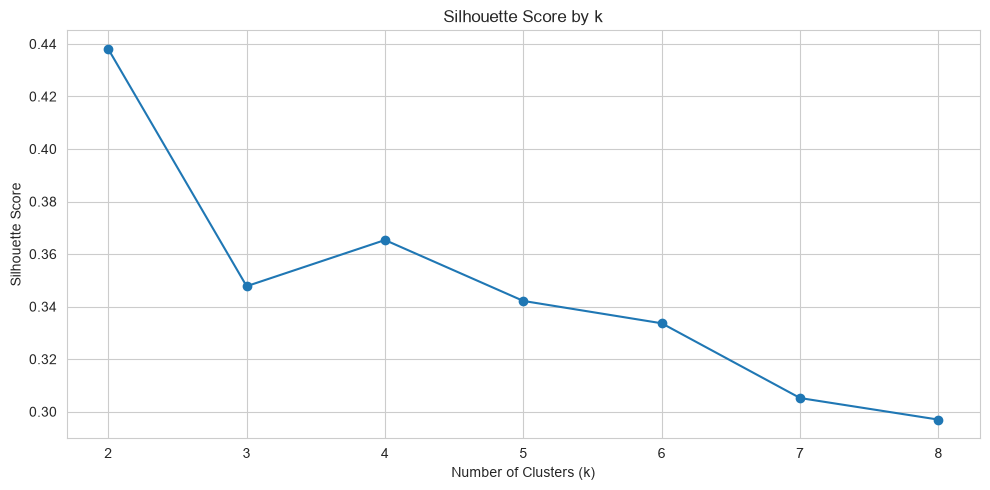

In [9]:
silhouette_scores = []
k_range_sil = range(2, 9)

for k in k_range_sil:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(
        rfm_scaled,
        labels
    )
    
    silhouette_scores.append(score)
    
    print(
        f"k={k}: silhouette score = {score:.4f}"
    )

plt.figure(figsize=(10, 5))

plt.plot(
    list(k_range_sil),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score by k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range_sil))

plt.tight_layout()

plt.savefig(
    '../images/silhouette_scores.png',
    dpi=150
)

plt.show()

In [10]:
# Select the k with the highest silhouette score
best_k = list(k_range_sil)[np.argmax(silhouette_scores)]

print(f"Best k based on silhouette score: {best_k}")

OPTIMAL_K = best_k

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

final_silhouette = silhouette_score(
    rfm_scaled,
    rfm['Cluster']
)

print(
    f"Final model: k={OPTIMAL_K}, "
    f"silhouette score = {final_silhouette:.4f}"
)

rfm[
    [
        'Customer ID',
        'Recency',
        'Frequency',
        'Monetary',
        'Cluster'
    ]
].head()

Best k based on silhouette score: 2
Final model: k=2, silhouette score = 0.4381


,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346,326,12,77556.46,0
1,12347,2,8,5633.32,0
2,12348,75,5,2019.40,0
3,12349,19,4,4428.69,0
4,12350,310,1,334.40,1


In [12]:
cluster_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(1).sort_values(
    'Avg_Monetary',
    ascending=False
)

cluster_profile

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,2352,51.2,12.6,6619.5
1,3526,301.5,2.1,616.7


In [13]:
# Display the cluster profile before assigning business labels
print("Cluster Profile:")
display(cluster_profile)

# Assign business-friendly labels based on the cluster profile.
# IMPORTANT: Update the mapping below according to your actual
# cluster_profile output.

cluster_labels = {
    0: 'High-Value Loyal',
    1: 'Recent Low-Spend',
    2: 'At Risk / Lapsing',
    3: 'Lost / Inactive'
}

# Apply labels
rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

# Check whether every cluster received a label
unmapped_clusters = rfm.loc[
    rfm['Cluster_Label'].isna(),
    'Cluster'
].unique()

if len(unmapped_clusters) > 0:
    print(
        "Warning: The following clusters do not have labels:",
        unmapped_clusters
    )
else:
    print("All clusters successfully labeled ")

# Display sample results
rfm[
    ['Customer ID', 'Recency', 'Frequency', 'Monetary',
     'Cluster', 'Cluster_Label']
].head(10)

Cluster Profile:


,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,2352,51.2,12.6,6619.5
1,3526,301.5,2.1,616.7


All clusters successfully labeled 


,Customer ID,Recency,Frequency,Monetary,Cluster,Cluster_Label
0,12346,326,12,77556.46,0,High-Value Loyal
1,12347,2,8,5633.32,0,High-Value Loyal
2,12348,75,5,2019.40,0,High-Value Loyal
3,12349,19,4,4428.69,0,High-Value Loyal
4,12350,310,1,334.40,1,Recent Low-Spend
5,12351,375,1,300.93,1,Recent Low-Spend
6,12352,36,10,2849.84,0,High-Value Loyal
7,12353,204,2,406.76,1,Recent Low-Spend
8,12354,232,1,1079.40,1,Recent Low-Spend
9,12355,214,2,947.61,1,Recent Low-Spend


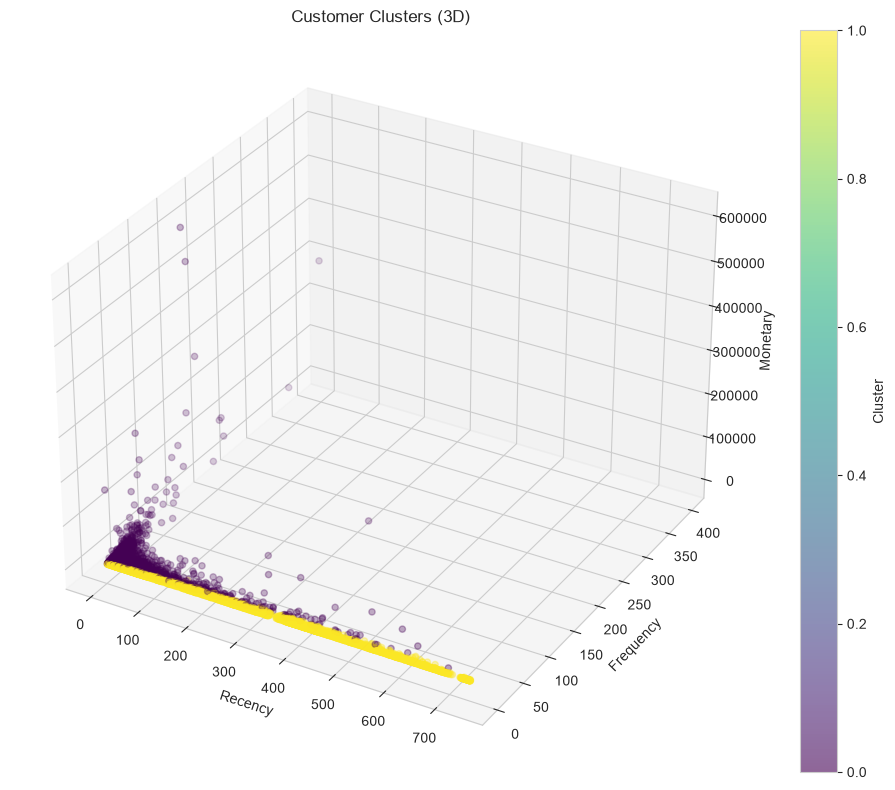

In [14]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

scatter = ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title(
    'Customer Clusters (3D)'
)

plt.colorbar(
    scatter,
    label='Cluster'
)

plt.tight_layout()

plt.savefig(
    '../images/kmeans_3d_clusters.png',
    dpi=150
)

plt.show()

In [15]:
output_path = "../data/processed/rfm_kmeans_table.csv"

rfm.to_csv(
    output_path,
    index=False
)

print(
    f"Saved clustered RFM table to {output_path}"
)

print(
    "Final shape:",
    rfm.shape
)

Saved clustered RFM table to ../data/processed/rfm_kmeans_table.csv
Final shape: (5878, 12)
